# 518880 `spread=1/2` 固定 Horizon Mid Direction

这个 notebook 只读取 [data/spread_horizon_direction](/home/jovyan/work/tactics_demo/518880/data/spread_horizon_direction) 下已经生成的 CSV。

标签口径：

- `mid_ret_tick_{h}s = (mid_{t+h} - mid_t) / tick`
- `up`: `mid_ret_tick > 0`
- `down`: `mid_ret_tick < 0`
- `flat`: `mid_ret_tick == 0`

为了保留双边交易视角，方向预测评估只在 `nonzero` 子样本上做，
但同时展示全样本的 `up/down/flat` 占比。


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / 'data').exists():
    if (BASE_DIR.parent / 'data').exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / '518880' / 'data').exists():
        BASE_DIR = BASE_DIR / '518880'
DATA_DIR = BASE_DIR / 'data' / 'spread_horizon_direction'

overview = pd.read_csv(DATA_DIR / 'overview.csv')
summary = pd.read_csv(DATA_DIR / 'summary.csv')
single = pd.read_csv(DATA_DIR / 'single_factor_auc.csv')
coef = pd.read_csv(DATA_DIR / 'logit_coef.csv')
bucket = pd.read_csv(DATA_DIR / 'bucket_view.csv')

print('data_dir =', DATA_DIR)


data_dir = /home/jovyan/work/tactics_demo/518880/data/spread_horizon_direction


## 1. 样本概览

In [2]:
display(overview)
display(summary)


,subset,samples,trade_days
0,spread1_all,653455,49
1,spread1_entry,33643,49
2,spread2_all,45599,49
3,spread2_entry,32627,49


,subset,horizon_s,samples_all,samples_nonzero,trade_days,up_ratio_all,down_ratio_all,flat_ratio_all,up_ratio_nonzero,avg_ret_tick,avg_abs_ret_tick,train_days,test_days,train_samples,test_samples,test_auc,test_accuracy,test_up_ratio_nonzero,test_avg_pred_prob
0,spread1_all,5,653238,307553,49,0.2354,0.2354,0.5292,0.5000,-0.0060,0.6615,34,15,207065,100488,0.7254,0.6666,0.4918,0.5022
1,spread1_all,10,653012,385764,49,0.2963,0.2945,0.4093,0.5015,-0.0120,1.0021,34,15,261138,124626,0.6652,0.6197,0.4908,0.5051
2,spread1_all,30,652086,493044,49,0.3795,0.3766,0.2439,0.5020,-0.0397,1.9311,34,15,337398,155646,0.5897,0.5634,0.4854,0.5079
3,spread1_entry,5,33631,23390,49,0.3460,0.3495,0.3045,0.4974,-0.0080,1.2897,34,15,14884,8506,0.7016,0.6459,0.4926,0.5028
4,spread1_entry,10,33616,25681,49,0.3805,0.3835,0.2360,0.4980,-0.0123,1.8513,34,15,16314,9367,0.6492,0.6050,0.4915,0.5045
5,spread1_entry,30,33575,28806,49,0.4323,0.4256,0.1420,0.5039,-0.0350,3.3685,34,15,18269,10537,0.5832,0.5559,0.4950,0.5112
6,spread2_all,5,45576,43093,49,0.4729,0.4726,0.0545,0.5002,-0.0130,1.3264,34,15,26723,16370,0.6141,0.5797,0.4857,0.5074
7,spread2_all,10,45560,44420,49,0.4884,0.4866,0.0250,0.5009,-0.0286,1.8857,34,15,27457,16963,0.5894,0.5626,0.4891,0.5075
8,spread2_all,30,45514,45031,49,0.5020,0.4873,0.0106,0.5074,-0.0475,3.3759,34,15,27819,17212,0.5546,0.5345,0.4969,0.5196
9,spread2_entry,5,32611,31037,49,0.4799,0.4718,0.0483,0.5043,-0.0115,1.3207,34,15,19774,11263,0.6152,0.5799,0.4921,0.5116


## 2. 样本外 AUC 对比

subset,spread1_all,spread1_entry,spread2_all,spread2_entry
horizon_s,,,,
5,0.7254,0.7016,0.6141,0.6152
10,0.6652,0.6492,0.5894,0.5917
30,0.5897,0.5832,0.5546,0.5539


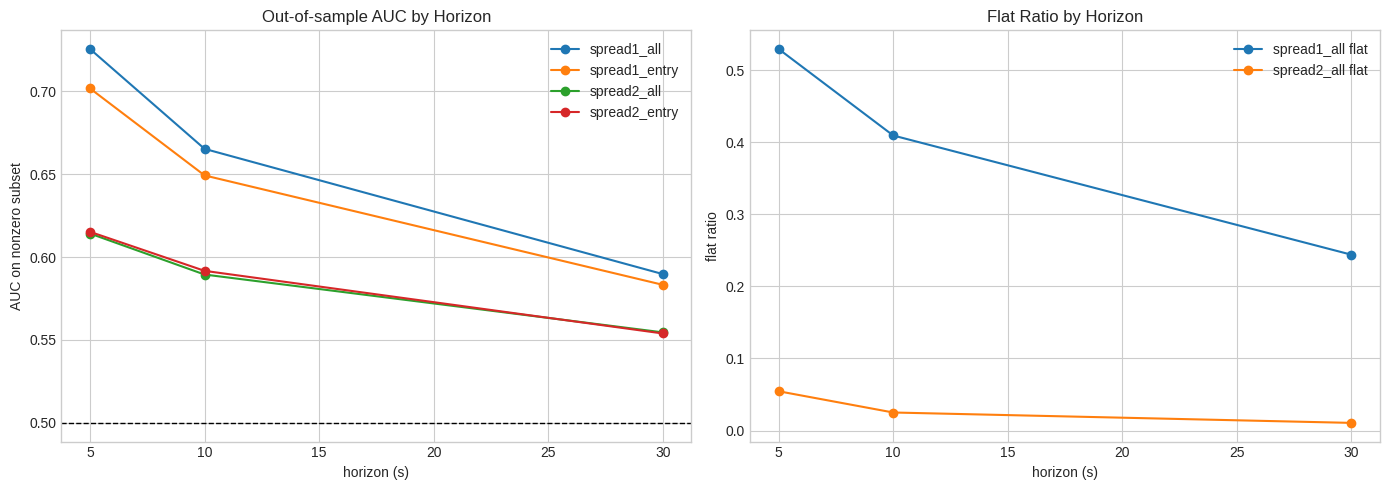

In [3]:
pivot_auc = summary.pivot(index='horizon_s', columns='subset', values='test_auc')
display(pivot_auc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for subset in ['spread1_all', 'spread1_entry', 'spread2_all', 'spread2_entry']:
    axes[0].plot(summary.loc[summary['subset'] == subset, 'horizon_s'], summary.loc[summary['subset'] == subset, 'test_auc'], marker='o', label=subset)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Out-of-sample AUC by Horizon')
axes[0].set_xlabel('horizon (s)')
axes[0].set_ylabel('AUC on nonzero subset')
axes[0].legend()

for subset in ['spread1_all', 'spread2_all']:
    sdf = summary.loc[summary['subset'] == subset]
    axes[1].plot(sdf['horizon_s'], sdf['flat_ratio_all'], marker='o', label=f'{subset} flat')
axes[1].set_title('Flat Ratio by Horizon')
axes[1].set_xlabel('horizon (s)')
axes[1].set_ylabel('flat ratio')
axes[1].legend()

fig.tight_layout()
plt.show()


## 3. `spread=2` 的方向分布

,subset,horizon_s,samples_all,samples_nonzero,trade_days,up_ratio_all,down_ratio_all,flat_ratio_all,up_ratio_nonzero,avg_ret_tick,avg_abs_ret_tick,train_days,test_days,train_samples,test_samples,test_auc,test_accuracy,test_up_ratio_nonzero,test_avg_pred_prob
6,spread2_all,5,45576,43093,49,0.4729,0.4726,0.0545,0.5002,-0.0130,1.3264,34,15,26723,16370,0.6141,0.5797,0.4857,0.5074
7,spread2_all,10,45560,44420,49,0.4884,0.4866,0.0250,0.5009,-0.0286,1.8857,34,15,27457,16963,0.5894,0.5626,0.4891,0.5075
8,spread2_all,30,45514,45031,49,0.5020,0.4873,0.0106,0.5074,-0.0475,3.3759,34,15,27819,17212,0.5546,0.5345,0.4969,0.5196
9,spread2_entry,5,32611,31037,49,0.4799,0.4718,0.0483,0.5043,-0.0115,1.3207,34,15,19774,11263,0.6152,0.5799,0.4921,0.5116
10,spread2_entry,10,32597,31841,49,0.4900,0.4868,0.0232,0.5016,-0.0243,1.8718,34,15,20228,11613,0.5917,0.5645,0.4921,0.5074
11,spread2_entry,30,32559,32235,49,0.5020,0.4881,0.0100,0.5070,-0.0438,3.3467,34,15,20476,11759,0.5539,0.5332,0.4944,0.5191


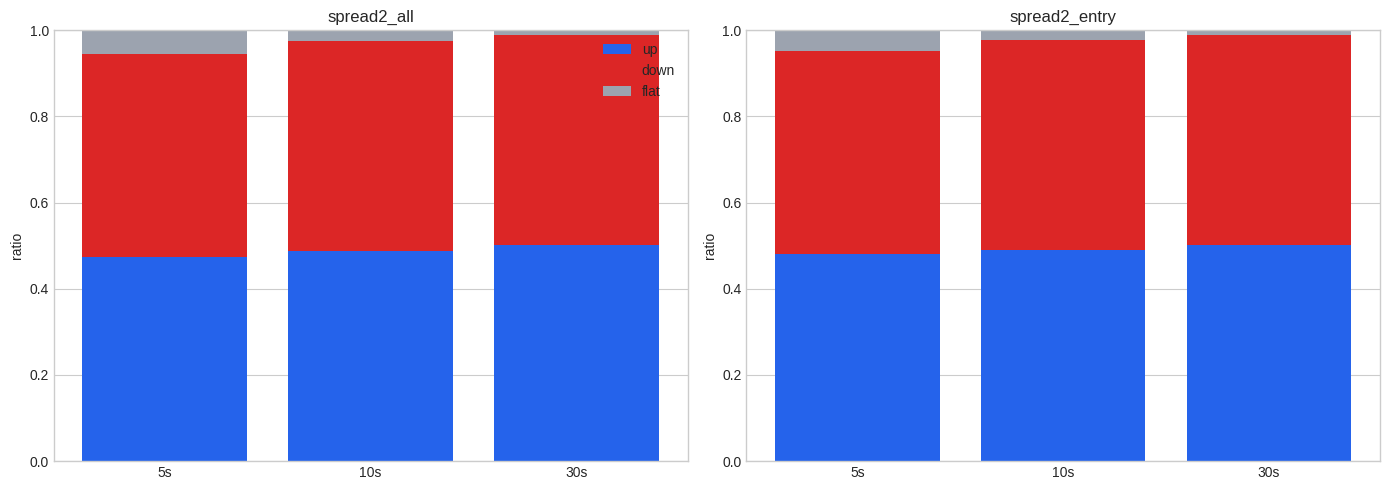

In [4]:
spread2 = summary[summary['subset'].isin(['spread2_all', 'spread2_entry'])].copy()
display(spread2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, subset in zip(axes, ['spread2_all', 'spread2_entry']):
    sdf = spread2[spread2['subset'] == subset].copy()
    x = np.arange(len(sdf))
    ax.bar(x, sdf['up_ratio_all'], label='up', color='#2563eb')
    ax.bar(x, sdf['down_ratio_all'], bottom=sdf['up_ratio_all'], label='down', color='#dc2626')
    ax.bar(x, sdf['flat_ratio_all'], bottom=sdf['up_ratio_all'] + sdf['down_ratio_all'], label='flat', color='#9ca3af')
    ax.set_xticks(x)
    ax.set_xticklabels(sdf['horizon_s'].astype(int).astype(str) + 's')
    ax.set_ylim(0, 1)
    ax.set_title(subset)
    ax.set_ylabel('ratio')
axes[0].legend()
fig.tight_layout()
plt.show()


## 4. Top 单因子

### spread2_all

#### horizon=5s

,subset,horizon_s,feature,auc,edge_over_random,corr_with_label
150,spread2_all,5,depth_skew_l1,0.5881,0.0881,0.1247
151,spread2_all,5,l1_imbalance,0.5878,0.0878,0.1520
152,spread2_all,5,l3_imbalance,0.5753,0.0753,0.1309
153,spread2_all,5,depth_skew_l3,0.5716,0.0716,0.1095
154,spread2_all,5,l5_imbalance,0.5563,0.0563,0.1011
155,spread2_all,5,depth_skew_l5,0.5521,0.0521,0.0735
156,spread2_all,5,bid_l1_change,0.5414,0.0414,0.0570
157,spread2_all,5,l1_imbalance_change,0.5378,0.0378,0.0708


#### horizon=10s

,subset,horizon_s,feature,auc,edge_over_random,corr_with_label
175,spread2_all,10,depth_skew_l1,0.5709,0.0709,0.1039
176,spread2_all,10,l1_imbalance,0.5681,0.0681,0.1181
177,spread2_all,10,l3_imbalance,0.5591,0.0591,0.1027
178,spread2_all,10,depth_skew_l3,0.5557,0.0557,0.0853
179,spread2_all,10,l5_imbalance,0.5456,0.0456,0.0844
180,spread2_all,10,depth_skew_l5,0.5417,0.0417,0.0601
181,spread2_all,10,bid_l1_change,0.5312,0.0312,0.0431
182,spread2_all,10,l1_imbalance_change,0.5288,0.0288,0.0533


...

,subset,horizon_s,feature,auc,edge_over_random,corr_with_label
225,spread2_entry,5,depth_skew_l1,0.5851,0.0851,0.1178
226,spread2_entry,5,l1_imbalance,0.5849,0.0849,0.1470
227,spread2_entry,5,l3_imbalance,0.5733,0.0733,0.1276
228,spread2_entry,5,depth_skew_l3,0.5692,0.0692,0.1061
229,spread2_entry,5,l5_imbalance,0.5542,0.0542,0.0979
230,spread2_entry,5,depth_skew_l5,0.5493,0.0493,0.0709
231,spread2_entry,5,bid_l1_change,0.5388,0.0388,0.0547
232,spread2_entry,5,active_vol_imbalance,0.5373,0.0373,0.0645


#### horizon=10s

,subset,horizon_s,feature,auc,edge_over_random,corr_with_label
250,spread2_entry,10,depth_skew_l1,0.5701,0.0701,0.1010
251,spread2_entry,10,l1_imbalance,0.5667,0.0667,0.1154
252,spread2_entry,10,l3_imbalance,0.5587,0.0587,0.1023
253,spread2_entry,10,depth_skew_l3,0.5550,0.0550,0.0852
254,spread2_entry,10,l5_imbalance,0.5441,0.0441,0.0822
255,spread2_entry,10,depth_skew_l5,0.5393,0.0393,0.0591
256,spread2_entry,10,bid_l1_change,0.5320,0.0320,0.0449
257,spread2_entry,10,net_active_vol,0.5298,0.0298,0.0490


#### horizon=30s

,subset,horizon_s,feature,auc,edge_over_random,corr_with_label
275,spread2_entry,30,depth_skew_l1,0.5409,0.0409,0.0614
276,spread2_entry,30,l3_imbalance,0.5383,0.0383,0.0671
277,spread2_entry,30,l1_imbalance,0.5373,0.0373,0.0646
278,spread2_entry,30,depth_skew_l3,0.5364,0.0364,0.0573
279,spread2_entry,30,l5_imbalance,0.5338,0.0338,0.0646
280,spread2_entry,30,depth_skew_l5,0.5317,0.0317,0.0522
281,spread2_entry,30,net_active_vol,0.5211,0.0211,0.0296
282,spread2_entry,30,net_active_turnover,0.5211,0.0211,0.0292


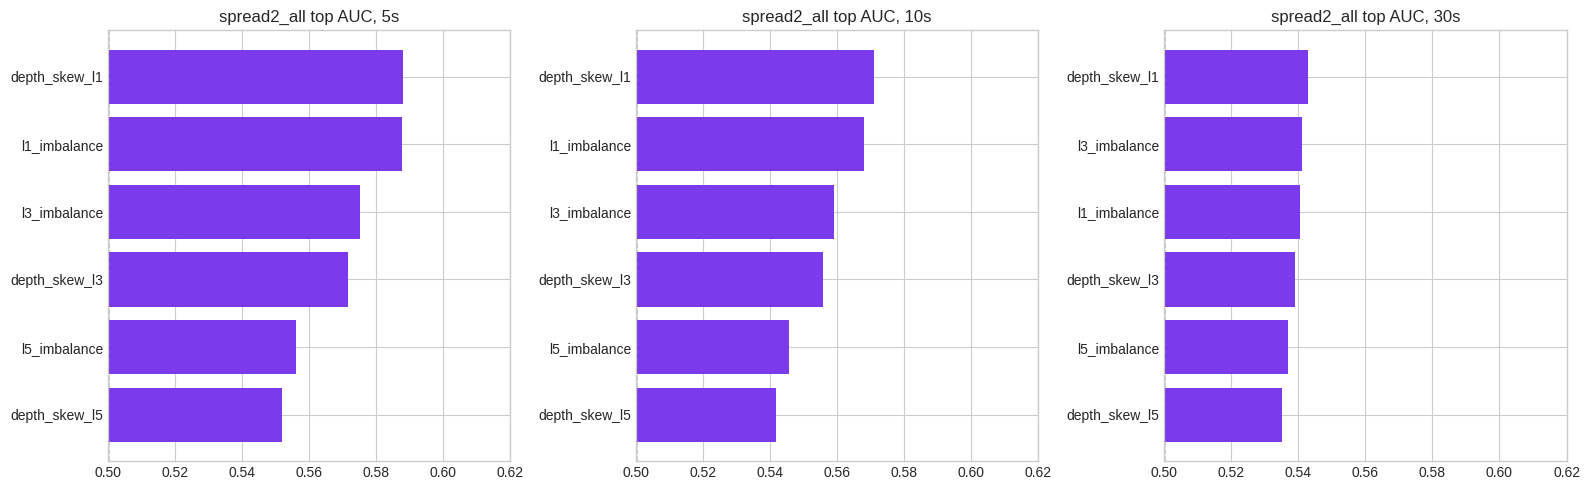

In [5]:
for subset in ['spread2_all', 'spread2_entry']:
    display(Markdown(f'### {subset}'))
    for horizon in [5, 10, 30]:
        top = single[(single['subset'] == subset) & (single['horizon_s'] == horizon)].head(8)
        display(Markdown(f'#### horizon={horizon}s'))
        display(top)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, horizon in zip(axes, [5, 10, 30]):
    sdf = single[(single['subset'] == 'spread2_all') & (single['horizon_s'] == horizon)].head(6).iloc[::-1]
    ax.barh(sdf['feature'], sdf['auc'], color='#7c3aed')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'spread2_all top AUC, {horizon}s')
    ax.set_xlim(0.5, max(0.62, sdf['auc'].max() + 0.02))
fig.tight_layout()
plt.show()


## 5. `spread=2` 的盘口失衡分桶

,subset,horizon_s,feature,bucket,samples,feature_mean,up_ratio,down_ratio,flat_ratio,mean_ret_tick
180,spread2_all,5,l1_imbalance,"(-1.001, -0.796]",4558,-0.9125,0.3613,0.5785,0.0601,-0.4566
181,spread2_all,5,l1_imbalance,"(-0.796, -0.575]",4558,-0.6832,0.3881,0.5553,0.0566,-0.1918
182,spread2_all,5,l1_imbalance,"(-0.575, -0.371]",4557,-0.4698,0.4093,0.5304,0.0603,-0.1813
183,spread2_all,5,l1_imbalance,"(-0.371, -0.183]",4558,-0.2761,0.4258,0.5193,0.0548,-0.1263
184,spread2_all,5,l1_imbalance,"(-0.183, 0.00468]",4557,-0.0874,0.4635,0.4821,0.0544,-0.0088
185,spread2_all,5,l1_imbalance,"(0.00468, 0.185]",4558,0.0937,0.4728,0.4746,0.0527,0.0014
186,spread2_all,5,l1_imbalance,"(0.185, 0.375]",4557,0.2796,0.5229,0.4251,0.0520,0.0790
187,spread2_all,5,l1_imbalance,"(0.375, 0.573]",4558,0.4731,0.5305,0.4228,0.0467,0.1075
188,spread2_all,5,l1_imbalance,"(0.573, 0.792]",4557,0.6800,0.5609,0.3860,0.0531,0.2531
189,spread2_all,5,l1_imbalance,"(0.792, 1.0]",4558,0.9072,0.5943,0.3517,0.0540,0.3932


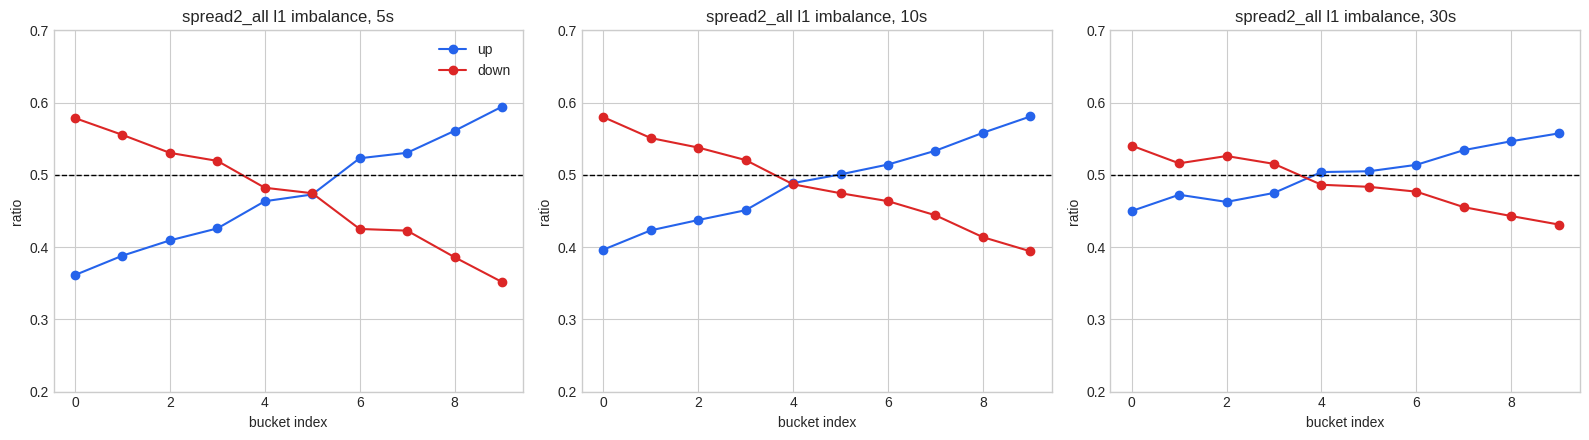

In [6]:
focus = bucket[(bucket['subset'] == 'spread2_all') & (bucket['feature'] == 'l1_imbalance')].copy()
display(focus.head(20))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, horizon in zip(axes, [5, 10, 30]):
    sdf = focus[focus['horizon_s'] == horizon].reset_index(drop=True)
    ax.plot(range(len(sdf)), sdf['up_ratio'], marker='o', label='up', color='#2563eb')
    ax.plot(range(len(sdf)), sdf['down_ratio'], marker='o', label='down', color='#dc2626')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'spread2_all l1 imbalance, {horizon}s')
    ax.set_xlabel('bucket index')
    ax.set_ylabel('ratio')
    ax.set_ylim(0.2, 0.7)
axes[0].legend()
fig.tight_layout()
plt.show()


## 6. 组合模型系数

In [7]:
for horizon in [5, 10, 30]:
    display(Markdown(f'### spread2_all horizon={horizon}s'))
    display(coef[(coef['subset'] == 'spread2_all') & (coef['horizon_s'] == horizon)].head(10))


### spread2_all horizon=5s

,subset,horizon_s,feature,coef
150,spread2_all,5,l1_imbalance,0.1893
151,spread2_all,5,l5_imbalance,0.1502
152,spread2_all,5,active_vol_imbalance,0.1396
153,spread2_all,5,depth_skew_l1,0.0906
154,spread2_all,5,depth_skew_l3,0.0795
155,spread2_all,5,l3_imbalance,0.0532
156,spread2_all,5,ask_l1_change,0.0391
157,spread2_all,5,bid_l5_change,0.0384
158,spread2_all,5,net_active_vol,0.0377
159,spread2_all,5,net_active_turnover,0.0327


### spread2_all horizon=10s

,subset,horizon_s,feature,coef
175,spread2_all,10,l5_imbalance,0.1861
176,spread2_all,10,depth_skew_l1,0.1309
177,spread2_all,10,l1_imbalance,0.1181
178,spread2_all,10,depth_skew_l3,0.0955
179,spread2_all,10,active_vol_imbalance,0.0824
180,spread2_all,10,bid_l5_change,0.0817
181,spread2_all,10,ask_l1_change,0.0644
182,spread2_all,10,net_active_vol,0.0478
183,spread2_all,10,active_vol,0.0233
184,spread2_all,10,l3_depth,0.0212


### spread2_all horizon=30s

,subset,horizon_s,feature,coef
200,spread2_all,30,active_vol,0.4840
201,spread2_all,30,net_active_vol,0.1349
202,spread2_all,30,depth_skew_l1,0.1206
203,spread2_all,30,l5_imbalance,0.1077
204,spread2_all,30,ask_l1_change,0.0481
205,spread2_all,30,l1_imbalance,0.0409
206,spread2_all,30,depth_skew_l3,0.0345
207,spread2_all,30,active_vol_imbalance,0.0281
208,spread2_all,30,bid_l5_change,0.0253
209,spread2_all,30,l1_imbalance_change,0.0110


## 7. 结论速记

In [8]:
s2 = summary[summary['subset'] == 'spread2_all'].set_index('horizon_s')
s1 = summary[summary['subset'] == 'spread1_all'].set_index('horizon_s')

msg = f'''
### 关键结论

- 固定 horizon 标签下，`spread=2` 在 `5s` 仍有一定方向预测力：样本外 `AUC={s2.loc[5, "test_auc"]:.3f}`。
- 到 `10s` 这个能力进一步下降到 `AUC={s2.loc[10, "test_auc"]:.3f}`，到 `30s` 只剩 `AUC={s2.loc[30, "test_auc"]:.3f}`，接近随机。
- `spread=2` 的 `flat` 比例很低：`5s` 只有 `{s2.loc[5, "flat_ratio_all"]:.1%}`，说明它主要不是“静止”，而是很快就有方向性波动。
- 但和 `spread=1` 相比，`spread=2` 的方向可预测性仍然更弱：`5s` 上 `spread1_all AUC={s1.loc[5, "test_auc"]:.3f}`，明显高于 `spread2_all AUC={s2.loc[5, "test_auc"]:.3f}`。
- 最稳定的解释变量仍然是 `L1/L3` 的盘口失衡与深度偏斜，但它们的 edge 会随着 horizon 拉长快速衰减。
'''

display(Markdown(msg))



### 关键结论

- 固定 horizon 标签下，`spread=2` 在 `5s` 仍有一定方向预测力：样本外 `AUC=0.614`。
- 到 `10s` 这个能力进一步下降到 `AUC=0.589`，到 `30s` 只剩 `AUC=0.555`，接近随机。
- `spread=2` 的 `flat` 比例很低：`5s` 只有 `5.4%`，说明它主要不是“静止”，而是很快就有方向性波动。
- 但和 `spread=1` 相比，`spread=2` 的方向可预测性仍然更弱：`5s` 上 `spread1_all AUC=0.725`，明显高于 `spread2_all AUC=0.614`。
- 最稳定的解释变量仍然是 `L1/L3` 的盘口失衡与深度偏斜，但它们的 edge 会随着 horizon 拉长快速衰减。
